# Phase 5 : Explainable AI (XAI)

This notebook explains why the machine learning model predicts customer churn.

Objectives

- Interpret the trained model
- Understand feature importance
- Explain individual predictions
- Generate business insights
- Improve model transparency

# Import Libraries

In [28]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report

# Load Model and Dataset

In [30]:
model = joblib.load("../models/final_churn_model.pkl")

preprocessor = joblib.load("../models/preprocessor.pkl")

X_test = pd.read_csv("../data/processed/X_test.csv")

y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [31]:
print(type(model))
print(type(preprocessor))

print(X_test.shape)
print(y_test.shape)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>
(1409, 51)
(1409,)


# Global Feature Importance

In [6]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance.head(20)

,Feature,Importance
38,cat__Contract_Month-to-month,0.109800
0,num__Tenure Months,0.108875
2,num__Total Charges,0.086351
3,num__Avg Monthly Spend,0.065312
1,num__Monthly Charges,0.064103
20,cat__Online Security_No,0.051403
29,cat__Tech Support_No,0.048466
18,cat__Internet Service_Fiber optic,0.046706
49,cat__Customer Age Group_New,0.044962
10,cat__Dependents_No,0.035103


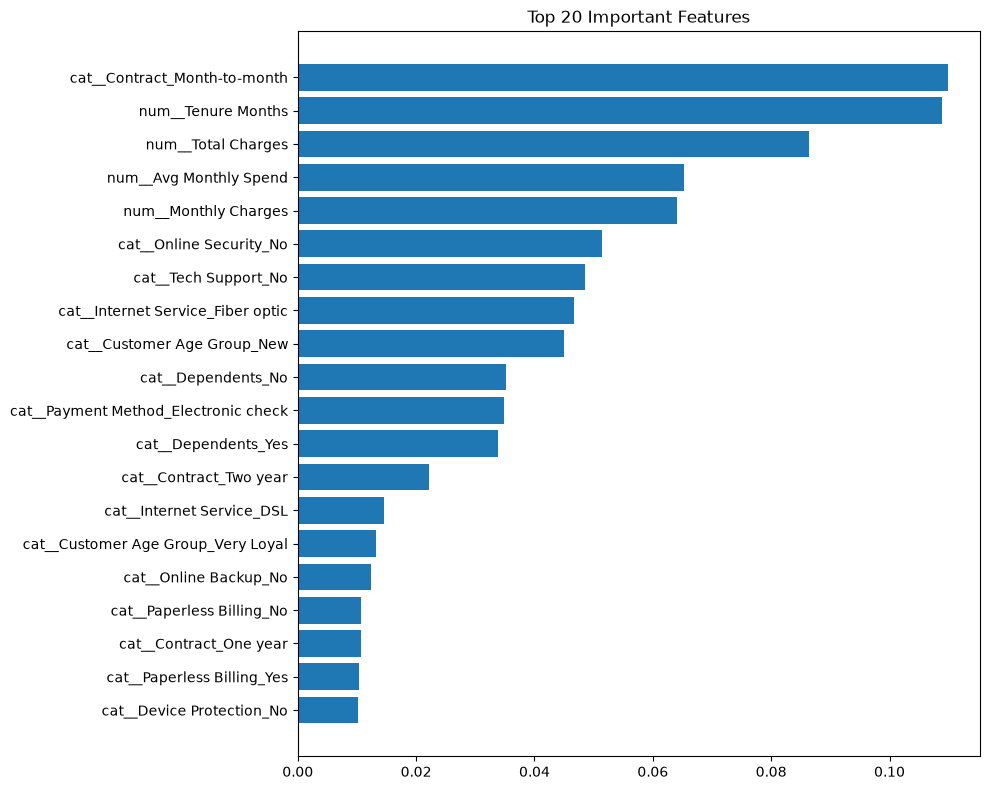

In [7]:
plt.figure(figsize=(10,8))

plt.barh(

    feature_importance.head(20)["Feature"],

    feature_importance.head(20)["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.tight_layout()

plt.show()

# SHAP Explainer

In [8]:
explainer = shap.TreeExplainer(model)

In [9]:
shap_values = explainer.shap_values(X_test)

In [32]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(1409, 51, 2)


# Global Feature Importance

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
38,cat__Contract_Month-to-month,0.109800
0,num__Tenure Months,0.108875
2,num__Total Charges,0.086351
3,num__Avg Monthly Spend,0.065312
1,num__Monthly Charges,0.064103
20,cat__Online Security_No,0.051403
29,cat__Tech Support_No,0.048466
18,cat__Internet Service_Fiber optic,0.046706
49,cat__Customer Age Group_New,0.044962
10,cat__Dependents_No,0.035103


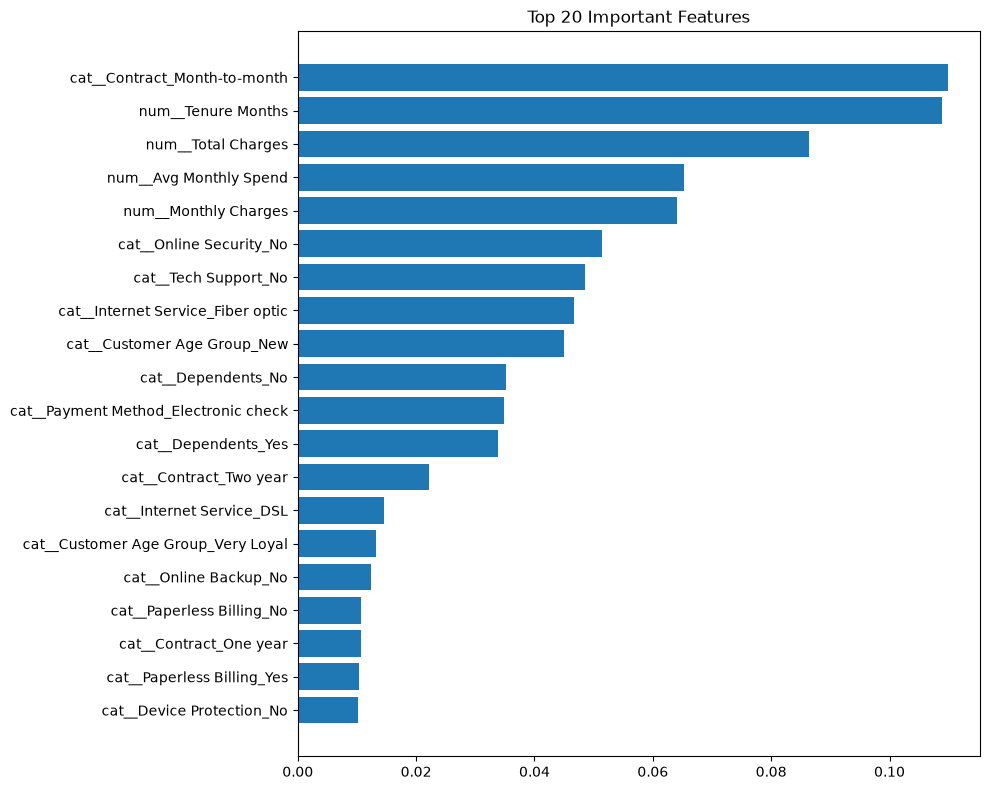

In [34]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance.head(20)["Feature"],
    feature_importance.head(20)["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.tight_layout()

plt.show()

# SHAP Beeswarm Plot

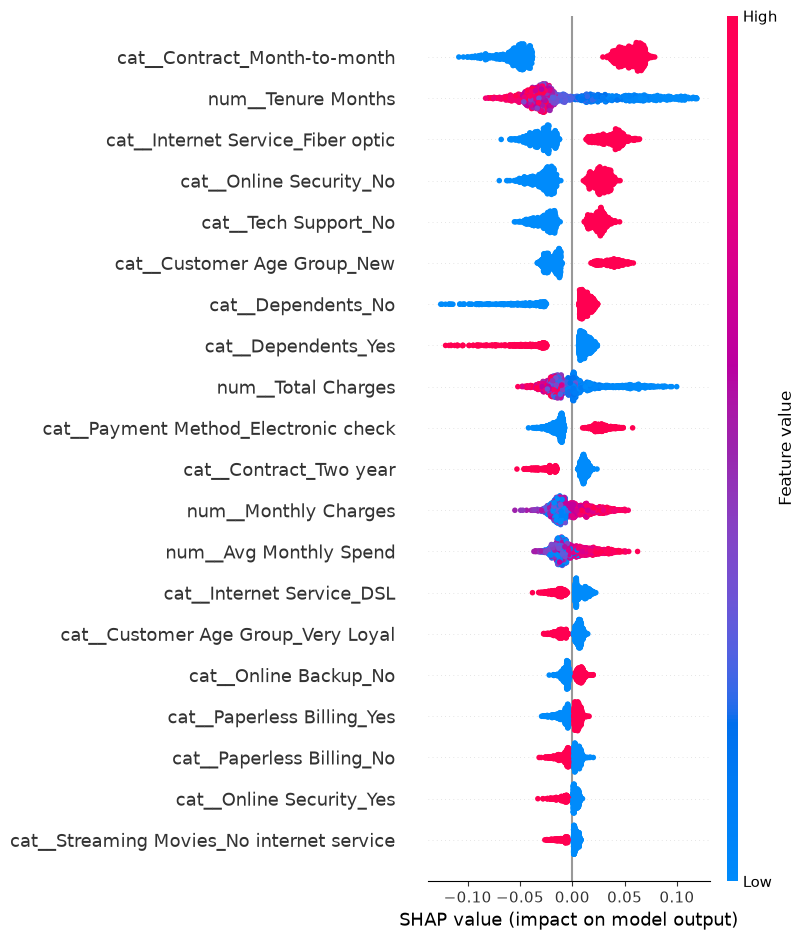

In [35]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

# SHAP Feature Importance

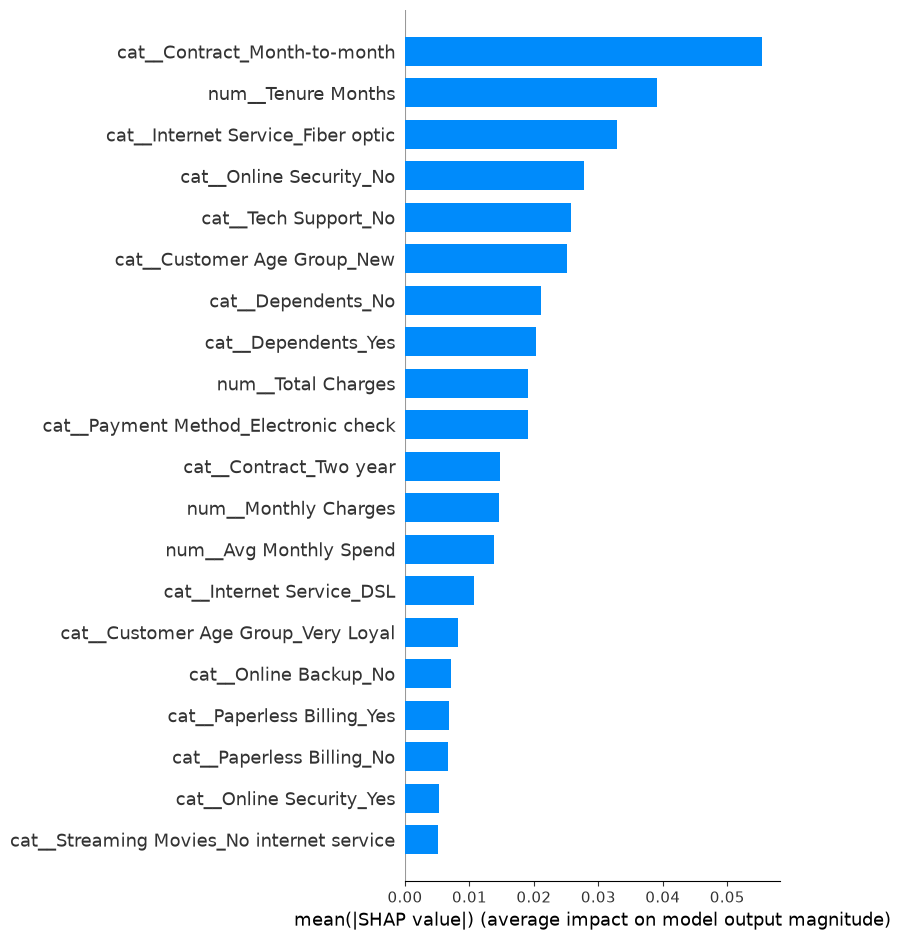

In [36]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar"
)

# Explain One Customer

In [37]:
sample_index = 0

class_index = 1

In [38]:
# Prediction
prediction = model.predict(
    X_test.iloc[[sample_index]]
)[0]

probability = model.predict_proba(
    X_test.iloc[[sample_index]]
)[0][1]

print("Prediction :", prediction)

print("Probability :", round(probability,4))

Prediction : 0
Probability : 0.0374


In [15]:
prediction = model.predict(

    X_test.iloc[[customer_index]]

)[0]

probability = model.predict_proba(

    X_test.iloc[[customer_index]]

)[0][1]

print("Prediction :", prediction)

print("Probability :", round(probability,4))

Prediction : 0
Probability : 0.0374


# Waterfall Plot

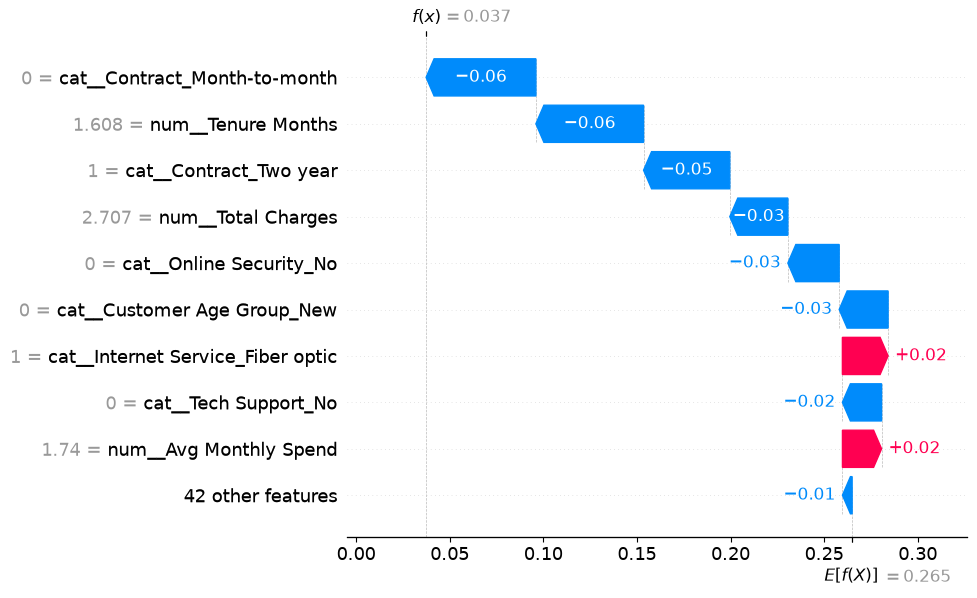

In [39]:
explanation = shap.Explanation(

    values=shap_values[sample_index,:,class_index],

    base_values=explainer.expected_value[class_index],

    data=X_test.iloc[sample_index].values,

    feature_names=X_test.columns.tolist()

)

shap.plots.waterfall(explanation)

# Force Plot

In [19]:
shap.initjs()

In [40]:
shap.force_plot(

    explainer.expected_value[class_index],

    shap_values[sample_index,:,class_index],

    X_test.iloc[sample_index]
)

# Decision Plot

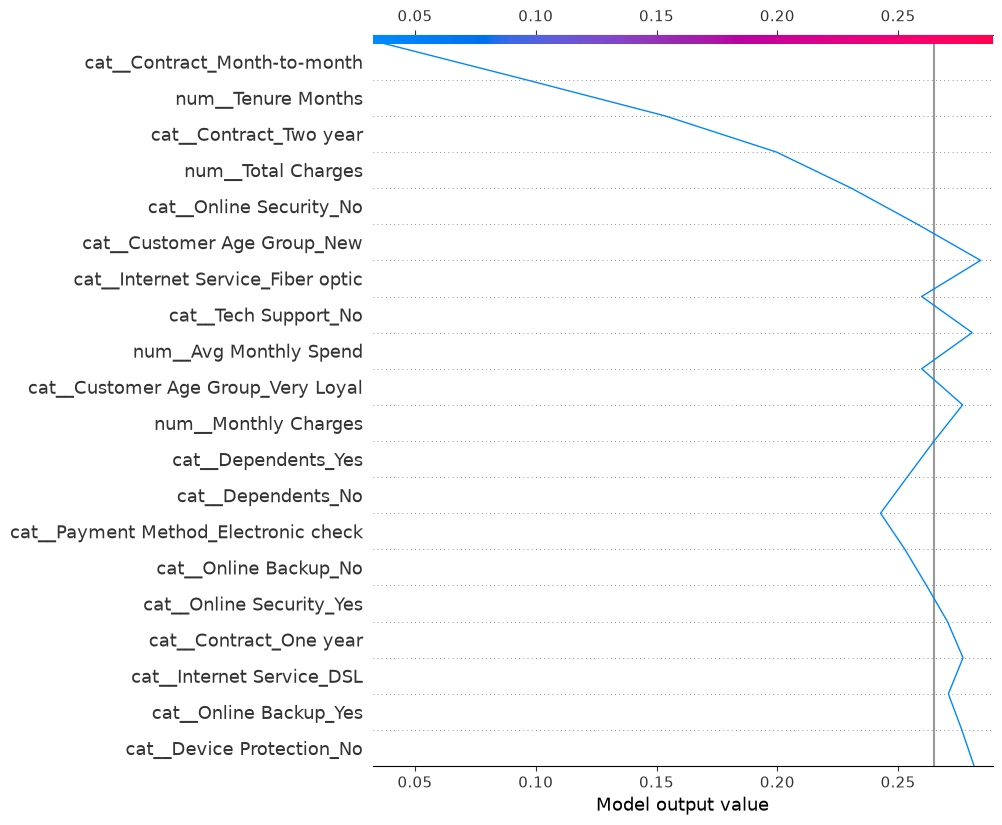

In [41]:
shap.decision_plot(

    explainer.expected_value[class_index],

    shap_values[sample_index,:,class_index],

    X_test.columns
)

# Customer Explanation Report

In [42]:
customer_report = pd.DataFrame({

    "Feature":X_test.columns,

    "SHAP Value":shap_values[sample_index,:,class_index],

    "Customer Value":X_test.iloc[sample_index].values

})

customer_report["Impact"] = np.where(

    customer_report["SHAP Value"]>0,

    "Increase Churn Risk",

    "Decrease Churn Risk"

)

customer_report = customer_report.reindex(

    customer_report["SHAP Value"].abs()

    .sort_values(ascending=False)

    .index

)

customer_report.head(20)

,Feature,SHAP Value,Customer Value,Impact
38,cat__Contract_Month-to-month,-0.058652,0.000000,Decrease Churn Risk
0,num__Tenure Months,-0.057509,1.608483,Decrease Churn Risk
40,cat__Contract_Two year,-0.046058,1.000000,Decrease Churn Risk
2,num__Total Charges,-0.031012,2.706828,Decrease Churn Risk
20,cat__Online Security_No,-0.027422,0.000000,Decrease Churn Risk
49,cat__Customer Age Group_New,-0.026126,0.000000,Decrease Churn Risk
18,cat__Internet Service_Fiber optic,0.024414,1.000000,Increase Churn Risk
29,cat__Tech Support_No,-0.020935,0.000000,Decrease Churn Risk
3,num__Avg Monthly Spend,0.020906,1.740482,Increase Churn Risk
50,cat__Customer Age Group_Very Loyal,-0.016943,1.000000,Decrease Churn Risk


# Business Recommendations

In [43]:
recommendations = []

top_features = customer_report.head(5)

for _, row in top_features.iterrows():

    feature = row["Feature"]

    if "Contract" in feature:

        recommendations.append(

            "Offer long-term contract incentives."

        )

    elif "Monthly Charges" in feature:

        recommendations.append(

            "Provide personalized pricing or discounts."

        )

    elif "Tech Support" in feature:

        recommendations.append(

            "Promote premium technical support."

        )

    elif "Online Security" in feature:

        recommendations.append(

            "Bundle online security services."

        )

    elif "Tenure" in feature:

        recommendations.append(

            "Offer loyalty rewards."

        )

In [44]:
recommendations = list(dict.fromkeys(recommendations))

recommendations

['Offer long-term contract incentives.',
 'Offer loyalty rewards.',
 'Bundle online security services.']

# Save Reports

In [45]:
feature_importance.to_csv(

    "../reports/feature_importance.csv",

    index=False

)

In [46]:
customer_report.to_csv(

    "../reports/customer_explanation.csv",

    index=False

)

# Phase Summary

In [47]:
summary = {

    "Model":"Random Forest",

    "Explainer":"TreeExplainer",

    "Test Samples":X_test.shape[0],

    "Features":X_test.shape[1],

    "Top Feature":

        feature_importance.iloc[0]["Feature"],

    "Prediction":

        prediction,

    "Prediction Probability":

        round(probability,4)

}

pd.DataFrame(

    summary.items(),

    columns=["Metric","Value"]

)

,Metric,Value
0,Model,Random Forest
1,Explainer,TreeExplainer
2,Test Samples,1409
3,Features,51
4,Top Feature,cat__Contract_Month-to-month
5,Prediction,0
6,Prediction Probability,0.0374
